# Ablation: Rank Loss Weight (λ_rank)

Comparing different rank loss weights:
- **λ_rank=0.1**: Low rank loss weight
- **λ_rank=0.2**: Light weight
- **λ_rank=0.3**: Medium-low weight
- **λ_rank=0.5**: Medium weight
- **λ_rank=1.0**: Full weight

In [1]:
import sys
import numpy as np
from pathlib import Path

# Import shared ablation utilities
from ablation_utils import (
    setup_plotting_style,
    load_all_ablation_models,
    load_all_models_all_metrics,
    make_latex_ablation_table,
    plot_ablation_line,
    plot_ablation_bars,
    compute_deltas,
    print_summary,
    METRICS, METRIC_DISPLAY, METRIC_COLORS
)

# Set up plotting style
setup_plotting_style()

In [11]:
# =============================================================================
# CONFIGURATION - Define ablation models
# =============================================================================

ABLATION_MODELS = {
    "CS-CLIP (λ_rank=0.0)": {
        "csv_path": "../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv",
        "is_baseline": True,
        "description": "No rank loss",
        "lambda_value": 0
    },
    "λ_rank=0.1": {
        "csv_path": "../evaluation/exp_csv/02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr0.1_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank_lambda_0.1.csv",
        "is_baseline": False,
        "description": "Low rank loss weight",
        "lambda_value": 0.1
    },
    "λ_rank=0.2": {
        "csv_path": "../evaluation/exp_csv/02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr0.2_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank_lambda_0.2.csv",
        "is_baseline": False,
        "description": "Light weight",
        "lambda_value": 0.2
    },
    "λ_rank=0.3": {
        "csv_path": "../evaluation/exp_csv/02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr0.3_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank_lambda_0.3.csv",
        "is_baseline": False,
        "description": "Medium-low weight",
        "lambda_value": 0.3
    },
    "λ_rank=0.5": {
        "csv_path": "../evaluation/exp_csv/02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank_lambda_0.5.csv",
        "is_baseline": False,
        "description": "Medium weight",
        "lambda_value": 0.5
    },
    "λ_rank=1.0": {
        "csv_path": "../evaluation/exp_csv/02-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_lr1.0_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rank_lambda_1.0.csv",
        "is_baseline": True,  # Mark one as baseline (adjust as needed)
        "description": "Full weight",
        "lambda_value": 1.0
    },
}

# Primary metric for comparison
PRIMARY_METRIC = "text_contrastive_accuracy"

# Checkpoint selection (use best or specific step)
CHECKPOINT_STEP = None  # None = use best checkpoint, or specify step like 5000

# Ablation metadata
ABLATION_NAME = "RANK LOSS WEIGHT ABLATION"
PARAM_KEY = "lambda_value"
PARAM_LABEL = r'$\lambda_{rank}$'

print("Ablation: Rank Loss Weight (λ_rank)")
print("="*50)
for name, cfg in ABLATION_MODELS.items():
    baseline_mark = " [BASELINE]" if cfg["is_baseline"] else ""
    print(f"  {name}{baseline_mark}: {cfg['description']}")

Ablation: Rank Loss Weight (λ_rank)
  CS-CLIP (λ_rank=0.0) [BASELINE]: No rank loss
  λ_rank=0.1: Low rank loss weight
  λ_rank=0.2: Light weight
  λ_rank=0.3: Medium-low weight
  λ_rank=0.5: Medium weight
  λ_rank=1.0 [BASELINE]: Full weight


In [12]:
# =============================================================================
# LOAD DATA - Single Metric (Primary)
# =============================================================================

scores_df = load_all_ablation_models(ABLATION_MODELS, PRIMARY_METRIC, CHECKPOINT_STEP)
print(f"\nLoaded {len(scores_df)} models, {len(scores_df.columns)} datasets")

Loading CS-CLIP (λ_rank=0.0)...
  Loaded 55 datasets (step=15000)
Loading λ_rank=0.1...
  Loaded 55 datasets (step=20000)
Loading λ_rank=0.2...
  Loaded 55 datasets (step=20000)
Loading λ_rank=0.3...
  Loaded 55 datasets (step=20000)
Loading λ_rank=0.5...
  Loaded 55 datasets (step=15000)
Loading λ_rank=1.0...
  Loaded 55 datasets (step=20000)

Common datasets (55): ['VisMin', 'BLA/ap', 'SugarCrepe_PP/replace_attribute', 'SugarCrepe/swap_obj', 'ControlledImages/VG-Two', 'NegBench/msr_vtt_mcq_rephrased_llama', 'COLA/multi_objects', 'VALSE/existence', 'BLA/co', 'SugarCrepe_PP/replace_relation', 'VG_Attribution', 'COCO_Counterfactuals', 'NegBench/VOC2007_mcq_llama3.1_rephrased', 'SPEC_I2T/count', 'VALSE/plurals', 'BLA/rc', 'SugarCrepe/add_att', 'VG_Relation', 'Winoground', 'COCO_Order', 'SPEC_I2T/relative_spatial', 'VALSE/counting', 'SugarCrepe/add_obj', 'ControlledImages/A', 'NegBench/COCO_val_mcq_llama3.1_rephrased', 'Flickr30k_Order', 'SPEC_I2T/relative_size', 'VALSE/relations', 'Color

In [13]:
# =============================================================================
# DISPLAY RAW SCORES TABLE
# =============================================================================

# Convert to percentage and display
scores_pct = scores_df * 100

# Add average column
scores_pct['Average'] = scores_pct.mean(axis=1)

print("\n" + "="*60)
print(f"ABLATION: RANK LOSS WEIGHT (λ_rank)")
print(f"Metric: {PRIMARY_METRIC}")
print("="*60)
display(scores_pct.round(1).style.highlight_max(axis=0, color='lightgreen'))


ABLATION: RANK LOSS WEIGHT (λ_rank)
Metric: text_contrastive_accuracy


,VisMin,BLA/ap,SugarCrepe_PP/replace_attribute,SugarCrepe/swap_obj,ControlledImages/VG-Two,NegBench/msr_vtt_mcq_rephrased_llama,COLA/multi_objects,VALSE/existence,BLA/co,SugarCrepe_PP/replace_relation,VG_Attribution,COCO_Counterfactuals,NegBench/VOC2007_mcq_llama3.1_rephrased,SPEC_I2T/count,VALSE/plurals,BLA/rc,SugarCrepe/add_att,VG_Relation,Winoground,COCO_Order,SPEC_I2T/relative_spatial,VALSE/counting,SugarCrepe/add_obj,ControlledImages/A,NegBench/COCO_val_mcq_llama3.1_rephrased,Flickr30k_Order,SPEC_I2T/relative_size,VALSE/relations,ColorSwap,SugarCrepe/replace_att,ControlledImages/B,SPEC_I2T/absolute_size,VALSE/actions,SugarCrepe_PP/swap_object,SugarCrepe/replace_obj,ControlledImages/COCO-One,SPEC_I2T/absolute_spatial,VALSE/coreference,SugarCrepe_PP/swap_atribute,SugarCrepe/replace_rel,ControlledImages/COCO-Two,SPEC_I2T/existence,VALSE/noun phrases,SugarCrepe_PP/replace_object,SugarCrepe/swap_att,ControlledImages/VG-One,MMVP/Camera Perspective,MMVP/Color,MMVP/Orientation,MMVP/Presence,MMVP/Quantity,MMVP/Spatial,MMVP/State,MMVP/Structural Character,MMVP/Text,Average
Model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CS-CLIP (λ_rank=0.0),78.600000,52.700000,74.200000,69.000000,53.100000,29.200000,41.000000,83.400000,48.400000,62.400000,70.000000,78.200000,37.800000,34.500000,70.500000,49.600000,80.800000,59.500000,29.800000,95.300000,29.500000,66.500000,90.800000,29.100000,31.400000,96.700000,32.700000,70.100000,59.000000,86.200000,34.600000,38.800000,83.200000,52.200000,94.900000,48.000000,12.200000,56.200000,56.500000,79.700000,50.900000,68.700000,93.700000,91.700000,74.500000,45.100000,6.700000,13.300000,13.300000,0.000000,6.700000,46.700000,13.300000,6.700000,13.300000,52.600000
λ_rank=0.1,78.000000,51.200000,74.500000,69.000000,51.600000,30.300000,35.200000,83.800000,48.500000,61.900000,68.800000,77.900000,37.500000,34.600000,69.700000,48.800000,82.100000,59.500000,28.700000,94.700000,28.700000,66.800000,90.200000,30.800000,31.300000,96.500000,31.000000,71.200000,58.700000,87.100000,34.600000,39.500000,83.800000,51.800000,94.300000,47.200000,12.100000,59.100000,57.700000,80.300000,49.800000,70.800000,93.600000,90.600000,76.100000,46.400000,13.300000,13.300000,6.700000,13.300000,0.000000,26.700000,13.300000,6.700000,6.700000,52.100000
λ_rank=0.2,77.200000,52.200000,73.100000,71.000000,53.900000,31.700000,39.500000,85.000000,48.400000,61.700000,69.400000,77.900000,37.600000,33.700000,69.400000,49.400000,80.600000,59.600000,29.000000,95.100000,28.700000,67.500000,89.800000,28.200000,32.400000,96.500000,31.400000,71.000000,57.300000,86.300000,36.000000,38.700000,84.100000,50.200000,94.500000,45.400000,12.700000,57.500000,58.400000,79.000000,49.300000,68.100000,93.700000,91.300000,74.000000,46.000000,0.000000,0.000000,13.300000,13.300000,13.300000,46.700000,6.700000,26.700000,0.000000,52.400000
λ_rank=0.3,77.800000,53.600000,73.600000,70.200000,54.700000,31.500000,40.000000,82.200000,47.900000,60.200000,68.600000,77.800000,37.400000,34.000000,69.900000,49.600000,81.500000,59.600000,29.500000,95.400000,28.000000,68.000000,88.800000,33.700000,30.700000,95.600000,32.000000,71.200000,59.700000,86.800000,36.500000,39.300000,83.500000,50.200000,93.700000,44.600000,12.200000,56.200000,55.900000,78.400000,49.500000,71.700000,93.500000,91.000000,73.300000,46.000000,6.700000,13.300000,13.300000,6.700000,0.000000,26.700000,13.300000,13.300000,0.000000,52.000000
λ_rank=0.5,78.300000,50.400000,73.100000,69.000000,52.700000,32.200000,37.600000,83.800000,47.600000,59.600000,68.400000,77.900000,39.300000,33.700000,68.900000,49.900000,77.700000,59.200000,31.000000,95.300000,29.300000,66.700000,88.100000,31.600000,34.800000,96.200000,31.600000,70.300000,60.000000,85.800000,34.300000,42.600000,82.500000,49.800000,94.600000,46.600000,12.600000,60.000000,53.600000,76.000000,50.200000,70.400000,93.800000,90.600000,71.800000,43.300000,20.000000,6.700000,13.300000,13.300000,6.700000,40.000000,6.700000,20.000000,0.000000,52.300000
λ_rank=1

In [14]:
# =============================================================================
# LOAD ALL METRICS (Text, Image, Group Contrastive Accuracy)
# =============================================================================

all_metrics_df = load_all_models_all_metrics(ABLATION_MODELS, METRICS, CHECKPOINT_STEP)

# Extract just the summary columns (I2T, T2I, Group)
summary_cols = [col for col in ['I2T', 'T2I', 'Group'] if col in all_metrics_df.columns]
summary_df = all_metrics_df[summary_cols].copy()

# Add overall average
summary_df['Average'] = summary_df.mean(axis=1)

print("\n" + "="*60)
print("ABLATION: RANK LOSS WEIGHT - ALL METRICS")
print("="*60)
display((summary_df * 100).round(1).style.highlight_max(axis=0, color='lightgreen'))

Loading CS-CLIP (λ_rank=0.0)...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ_rank=0.1...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ_rank=0.2...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ_rank=0.3...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ_rank=0.5...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ_rank=1.0...
  Loaded metrics: ['I2T', 'T2I', 'Group']

Common datasets across all models (17): ['BLA', 'COCO_Counterfactuals', 'COCO_Order', 'COLA', 'ColorSwap', 'ControlledImages', 'Flickr30k_Order', 'MMVP', 'NegBench', 'SPEC_I2T', 'SugarCrepe', 'SugarCrepe_PP', 'VALSE', 'VG_Attribution', 'VG_Relation', 'VisMin', 'Winoground']

ABLATION: RANK LOSS WEIGHT - ALL METRICS


,I2T,T2I,Group,Average
Model,,,,
CS-CLIP (λ_rank=0.0),59.300000,41.600000,25.400000,42.100000
λ_rank=0.1,58.600000,41.200000,24.400000,41.400000
λ_rank=0.2,58.900000,40.800000,25.000000,41.600000
λ_rank=0.3,58.900000,40.700000,24.900000,41.500000
λ_rank=0.5,59.000000,40.800000,25.300000,41.700000
λ_rank=1.0,58.800000,41.100000,24.300000,41.400000


In [15]:
# =============================================================================
# LATEX TABLE GENERATION
# =============================================================================

latex_table = make_latex_ablation_table(
    summary_df,
    ABLATION_MODELS,
    caption="Rank loss weight ($\\lambda_{\\text{rank}}$) ablation. I2T = Image-to-Text, T2I = Text-to-Image, Group = both correct. Best in \\textbf{bold}, baseline \\underline{underlined}.",
    label="tab:ablation_rank_lambda",
)

print("="*60)
print("LATEX TABLE")
print("="*60)
print(latex_table)

LATEX TABLE
\begin{table}[t]
  \centering
  \small
  \caption{Rank loss weight ($\lambda_{\text{rank}}$) ablation. I2T = Image-to-Text, T2I = Text-to-Image, Group = both correct. Best in \textbf{bold}, baseline \underline{underlined}.}
  \label{tab:ablation_rank_lambda}
  \begin{tabular}{lcccc}
    \toprule
    Model & I2T & T2I & Group & Average \\
    \midrule
    CS-CLIP (λ\_rank=0.0) & \textbf{\underline{59.3}} & \textbf{\underline{41.6}} & \textbf{\underline{25.4}} & \textbf{\underline{42.1}} \\
    λ\_rank=0.1 & 58.6 & 41.2 & 24.4 & 41.4 \\
    λ\_rank=0.2 & 58.9 & 40.8 & 25.0 & 41.6 \\
    λ\_rank=0.3 & 58.9 & 40.7 & 24.9 & 41.5 \\
    λ\_rank=0.5 & 59.0 & 40.8 & 25.3 & 41.7 \\
    λ\_rank=1.0 & 58.8 & 41.1 & 24.3 & 41.4 \\
    \bottomrule
  \end{tabular}
\end{table}


Saved: ../paper_figures/ablation_rank_lambda_line.pdf


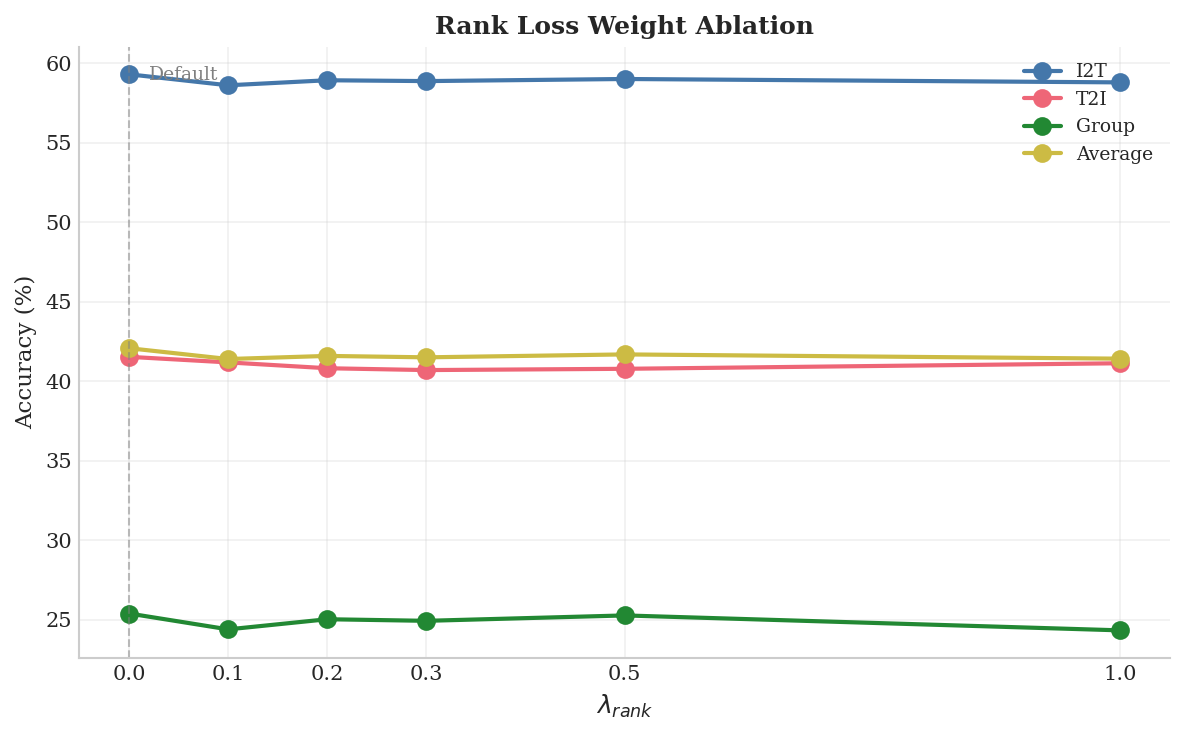

In [16]:
# =============================================================================
# VISUALIZATION: LINE PLOT (λ vs Performance)
# =============================================================================

fig, ax = plot_ablation_line(
    summary_df,
    ABLATION_MODELS,
    param_key=PARAM_KEY,
    param_label=PARAM_LABEL,
    title='Rank Loss Weight Ablation',
    save_path='../paper_figures/ablation_rank_lambda_line.pdf'
)

Saved: ../paper_figures/ablation_rank_lambda_bars.pdf


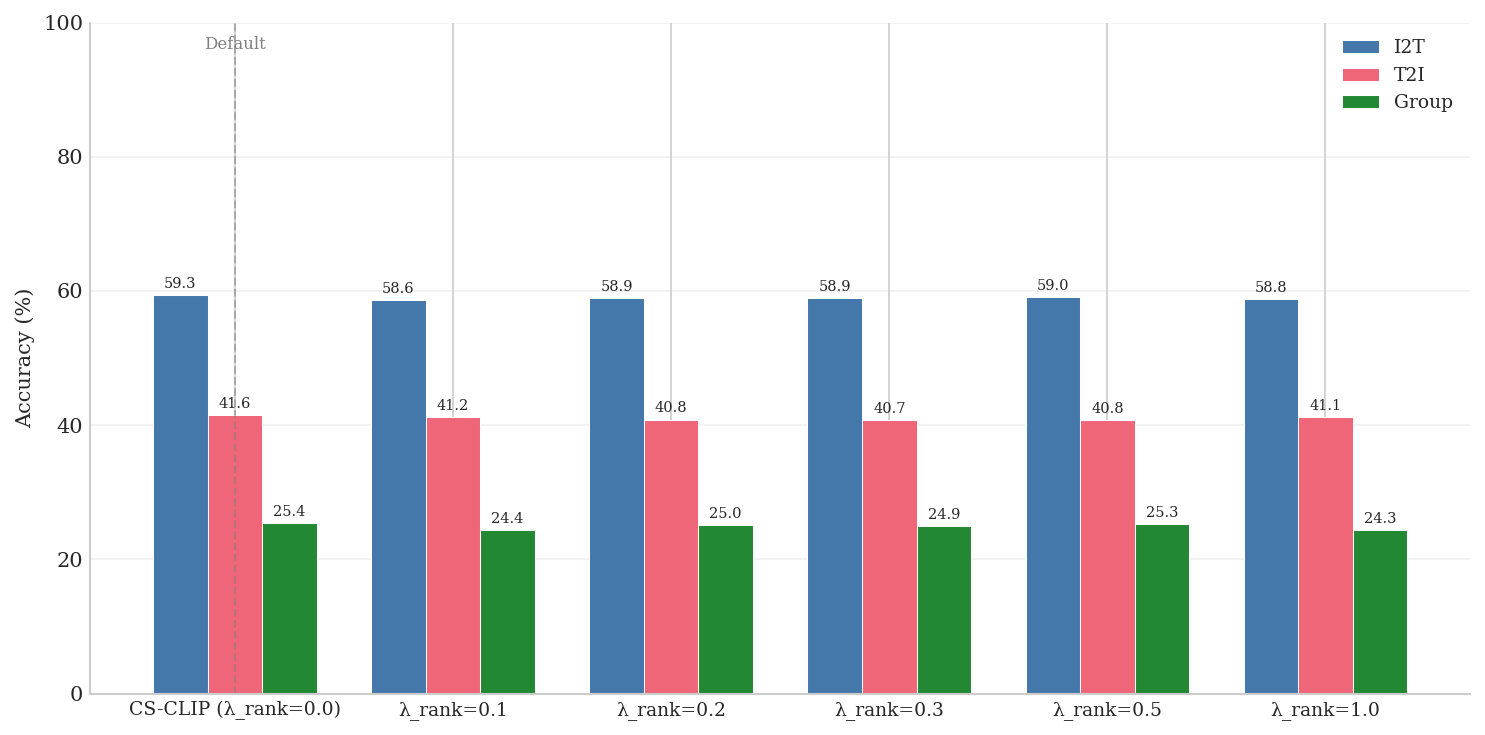

In [17]:
# =============================================================================
# VISUALIZATION: GROUPED BAR CHART (All Metrics)
# =============================================================================

fig, ax = plot_ablation_bars(
    summary_df,
    ABLATION_MODELS,
    title='Rank Loss Weight Ablation',
    save_path='../paper_figures/ablation_rank_lambda_bars.pdf'
)

In [18]:
# =============================================================================
# COMPUTE DELTAS FROM BASELINE
# =============================================================================

baseline_model = [name for name, cfg in ABLATION_MODELS.items() if cfg['is_baseline']][0]
print(f"Baseline model: {baseline_model}")

deltas_df = compute_deltas(summary_df, ABLATION_MODELS)

print("\n" + "="*60)
print("DELTA FROM BASELINE (percentage points)")
print("="*60)
display(deltas_df.round(2).style.background_gradient(cmap='RdYlGn', axis=None))

Baseline model: CS-CLIP (λ_rank=0.0)

DELTA FROM BASELINE (percentage points)


,I2T,T2I,Group,Average
Model,,,,
CS-CLIP (λ_rank=0.0),0.000000,0.000000,0.000000,0.000000
λ_rank=0.1,-0.690000,-0.350000,-1.000000,-0.680000
λ_rank=0.2,-0.370000,-0.720000,-0.360000,-0.480000
λ_rank=0.3,-0.430000,-0.830000,-0.460000,-0.570000
λ_rank=0.5,-0.300000,-0.750000,-0.120000,-0.390000
λ_rank=1.0,-0.510000,-0.400000,-1.060000,-0.660000


In [19]:
# =============================================================================
# SUMMARY
# =============================================================================

print_summary(summary_df, ABLATION_MODELS, ABLATION_NAME, PARAM_KEY)


SUMMARY: RANK LOSS WEIGHT ABLATION

Baseline: CS-CLIP (λ_rank=0.0)

Average Performance:
  ★ CS-CLIP (λ_rank=0.0): 42.1% (+0.00pp vs baseline) | lambda_value=0
    λ_rank=0.1: 41.4% (-0.68pp vs baseline) | lambda_value=0.1
    λ_rank=0.2: 41.6% (-0.48pp vs baseline) | lambda_value=0.2
    λ_rank=0.3: 41.5% (-0.57pp vs baseline) | lambda_value=0.3
    λ_rank=0.5: 41.7% (-0.39pp vs baseline) | lambda_value=0.5
  ★ λ_rank=1.0: 41.4% (-0.66pp vs baseline) | lambda_value=1.0

Key Findings:
  - Best: CS-CLIP (λ_rank=0.0) (42.1%)
  - Worst: λ_rank=0.1 (41.4%)
  - Gap: 0.7pp


In [ ]:
# =============================================================================
# DATASET-WISE AND SUBSET-WISE TABLES (with ARO merging)
# =============================================================================

from ablation_utils import (
    load_all_models_per_dataset,
    load_all_models_per_subset,
    make_latex_dataset_table,
    get_datasets_and_subsets,
    display_all_tables,
    load_benchmark_config
)

# Load benchmark config for dataset merge rules (e.g., ARO)
bench_cfg = load_benchmark_config()

# Display all tables for the primary metric (I2T) with ARO merging
dataset_df, subset_df, datasets_subsets = display_all_tables(
    ABLATION_MODELS, PRIMARY_METRIC, CHECKPOINT_STEP, 
    show_latex=True, apply_merge=True, benchmark_config=bench_cfg
)

In [ ]:
# =============================================================================
# PER-DATASET LATEX TABLE (for specific datasets with subsets)
# =============================================================================

# Generate separate tables for datasets with multiple subsets
for dataset_name, subsets in sorted(datasets_subsets.items()):
    if len(subsets) > 1:  # Only show datasets with multiple subsets
        print(f"\n{'='*60}")
        print(f"DATASET: {dataset_name} (subsets: {subsets})")
        print("="*60)
        
        # Filter subset_df to only this dataset
        cols = [c for c in subset_df.columns if c.startswith(f"{dataset_name}/") or c == dataset_name]
        if cols:
            ds_df = subset_df[cols]
            ds_pct = ds_df * 100
            ds_pct['Avg'] = ds_pct.mean(axis=1)
            display(ds_pct.round(1).style.highlight_max(axis=0, color='lightgreen'))
            
            # LaTeX
            print("\nLaTeX:")
            print(make_latex_dataset_table(
                ds_df, ABLATION_MODELS,
                caption=f"{dataset_name} subset breakdown (I2T accuracy).",
                label=f"tab:ablation_{dataset_name.lower()}_subsets",
                rotate_headers=False
            ))